# Experiment 2 — Partial 30% Fine-Tuning of ResNet18 for CDT Classification

**Project:** Deep Learning-Based Approach for Cognitive Decline Screening Through Clock Drawing Test Image Analysis  
**Experiment:** Experiment 2 — Partial 30% Fine-Tuning  
**Model Setup:** ImageNet-pretrained ResNet18 backbone with the last 30% of layers unfrozen  
**Output Classes:** `Impaired`, `Mild`, `Normal`

<br>

---

<br>

## Experiment Purpose

Experiment 2 evaluates whether partial fine-tuning improves CDT image classification compared with the fully frozen baseline.

The last 30% of the ImageNet-pretrained ResNet18 backbone is made trainable, while the earlier layers remain frozen. This allows the model to adapt higher-level visual features to the CDT dataset while still preserving general pretrained features.

<br>

---

<br>

## Main Difference from Experiments 1 and 3

| Experiment | Backbone Setup | Imbalance Handling | Purpose |
|---|---|---|---|
| Experiment 1 | Fully frozen backbone | Standard augmentation | Baseline feature extraction |
| Experiment 2 | Last 30% unfrozen | Standard augmentation | Partial adaptation |
| Experiment 3 | 100% trainable backbone | Oversampling + class weights | Full adaptation with minority-class support |

<br>

> **Research note:** Experiment 2 tests whether partial feature adaptation improves classification performance without fully retraining the entire ResNet18 backbone.

---
# Section 1 — Environment Setup and Library Imports

The required libraries are prepared for model loading, dataset processing, partial fine-tuning, training, visualization, and evaluation.

In [ ]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# ============================================================

!pip install -q keras-hub keras

import os
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import keras
import keras_hub
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

print("Keras version      :", keras.__version__)
print("TensorFlow version :", tf.__version__)

Environment ready.
Keras version      : 3.13.2
TensorFlow version : 2.20.0


---
# Section 2 — Load the ImageNet-Pretrained ResNet18 Backbone

An ImageNet-pretrained ResNet18 backbone is initialized through KerasHub. This backbone provides the pretrained visual feature extractor used for partial fine-tuning.

<br>

> **Research note:** In Experiment 2, the earlier backbone layers remain frozen while the last 30% of layers are allowed to adapt to CDT image patterns.

In [ ]:
# ============================================================
# SECTION 2: LOAD PRETRAINED RESNET18 BACKBONE
# ============================================================

backbone = keras_hub.models.ResNetBackbone.from_preset("resnet_18_imagenet")

print("ResNet18 backbone loaded successfully.")
print("Expected input shape : (None, 224, 224, 3)")
print("Total backbone layers:", len(backbone.layers))

ResNet18 backbone loaded successfully.
Expected input shape : (None, 224, 224, 3)
Total backbone layers: 72


## Section 2.1 — Inspect the Backbone Before Partial Fine-Tuning

The backbone architecture is reviewed before applying the 30% unfreezing setup. Trainable-layer verification is performed later after the partial fine-tuning configuration is applied.

In [ ]:
# ============================================================
# SECTION 2.1: BACKBONE INSPECTION BEFORE FINE-TUNING
# ============================================================

backbone.summary()

print("\nLast 10 backbone layers:")
for layer in backbone.layers[-10:]:
    print(f"{layer.name:<45} | {layer.__class__.__name__:<25} | trainable: {layer.trainable}")

Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │     36,864 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_add   │ (None, None,      │          0 │ pool1_pool[0][0], │
│ (Add)               │ None, 64)         │            │ stack0_block0_2_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_out   │ (None, None,      │          0 │ stack0_block0_ad… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_co… │ (None, None,      │     36,864 │ stack0_block0_ou… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_bn  │ (None, None,      │        256 │ stack0_block1_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_re… │ (None, None,      │          0 │ stack0_block1_1_

 Total params: 11,186,112 (42.67 MB)

 Trainable params: 11,176,512 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)


Last 10 backbone layers:
stack3_block0_2_bn                            | BatchNormalization        | trainable: True
stack3_block0_add                             | Add                       | trainable: True
stack3_block0_out                             | Activation                | trainable: True
stack3_block1_1_conv                          | Conv2D                    | trainable: True
stack3_block1_1_bn                            | BatchNormalization        | trainable: True
stack3_block1_1_relu                          | Activation                | trainable: True
stack3_block1_2_conv                          | Conv2D                    | trainable: True
stack3_block1_2_bn                            | BatchNormalization        | trainable: True
stack3_block1_add                             | Add                       | trainable: True
stack3_block1_out                             | Activation                | trainable: True


---
# Section 3 — Mount Google Drive and Load the CDT Dataset

Google Drive is mounted to access the 3-class Clock Drawing Test dataset.

Expected folder structure:

```text
Experiment_data_3class/
├── Impaired/
├── Mild/
└── Normal/

In [ ]:

# ============================================================
# SECTION 3: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# SECTION 3.1: DATASET AND OUTPUT CONFIGURATION
# ============================================================

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
SEED = 123

# Dataset path.
FOLDER_PATH = "/content/drive/MyDrive/Colab Notebooks/Experiment_data_3class"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/models"

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "exp2_partial30_resnet18_best.keras")
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "exp2_partial30_resnet18_final.keras")
SUMMARY_CSV_PATH = os.path.join(SAVE_DIR, "exp2_summary_metrics.csv")
PER_CLASS_CSV_PATH = os.path.join(SAVE_DIR, "exp2_per_class_metrics.csv")

print("Dataset path     :", FOLDER_PATH)
print("Best model path  :", BEST_MODEL_PATH)
print("Final model path :", FINAL_MODEL_PATH)

Configuration loaded.
Dataset path     : /content/drive/MyDrive/Colab Notebooks/Experiment_data_3class
Best model path  : /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras
Final model path : /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_final.keras


In [ ]:
# ============================================================
# SECTION 3.2: LOAD TRAINING AND VALIDATION DATASETS
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=FOLDER_PATH,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    interpolation="area",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=FOLDER_PATH,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    interpolation="area",
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names       :", class_names)
print("Number of classes :", num_classes)

Found 1638 files belonging to 3 classes.
Using 1311 files for training.
Found 1638 files belonging to 3 classes.
Using 327 files for validation.

Dataset loaded.
Class names       : ['Impaired', 'Mild', 'Normal']
Number of classes : 3


## Section 3.3 — Check Class Distribution

The class distribution is examined for both training and validation sets. This is necessary because imbalanced class counts can cause the model to favor the majority class.

<br>

> **Research note:** Class-level metrics such as precision, recall, F1-score, macro average, and confusion matrix are used because accuracy alone may not fully represent model behavior.

In [ ]:
# ============================================================
# SECTION 3.3: CLASS DISTRIBUTION CHECK
# ============================================================

def count_dataset_classes(dataset, class_names):
    counter = Counter()

    for _, labels in dataset.unbatch():
        counter[int(labels.numpy())] += 1

    for class_index, count in sorted(counter.items()):
        print(f"{class_names[class_index]:<12}: {count} samples")

    return counter


print("Training Set Distribution")
print("-" * 35)
train_counts = count_dataset_classes(train_ds, class_names)

print("\nValidation Set Distribution")
print("-" * 35)
val_counts = count_dataset_classes(val_ds, class_names)

Training Set Distribution
-----------------------------------
Impaired    : 70 samples
Mild        : 288 samples
Normal      : 953 samples

Validation Set Distribution
-----------------------------------
Impaired    : 16 samples
Mild        : 64 samples
Normal      : 247 samples


---
# Section 4 — Normalize the Images

Pixel values are scaled from `[0, 255]` to `[0.0, 1.0]` to support more stable and efficient model training.

In [ ]:
# ============================================================
# SECTION 4: IMAGE NORMALIZATION
# ============================================================

def normalize_image(image, label):
    """Convert image pixels from [0, 255] to [0.0, 1.0]."""
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


train_ds = train_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

Normalization complete. Pixel values are now scaled to [0.0, 1.0].


---
# Section 5 — Data Augmentation

Online augmentation is applied only to the training set to improve robustness against small variations in CDT images.

The validation set remains unchanged to preserve a realistic evaluation setup.

Applied transformations:

- Horizontal flip
- Rotation
- Zoom
- Translation
- Contrast adjustment

<br>

> **Implementation note:** Augmentation is applied dynamically during training and does not create additional saved image files.

In [ ]:
# ============================================================
# SECTION 5: ONLINE DATA AUGMENTATION
# ============================================================

data_augmentation_layers = [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10),
]

def augment_images(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    return images, labels


augmented_train_ds = train_ds.map(
    augment_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

augmented_train_ds = augmented_train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


Online augmentation configured for the training set only.
Augmentations: Flip | Rotation | Zoom | Translation | Contrast


## Section 5.1 — Augmentation Exposure Estimate

Dynamic augmentation keeps the number of saved image files unchanged. Instead, the model is exposed to transformed training views across epochs.

```text
Approximate exposure = training images per epoch × completed epochs

In [ ]:
# ============================================================
# SECTION 5.1: AUGMENTATION EXPOSURE NOTE
# ============================================================

train_total = sum(train_counts.values())

print("Training images per epoch :", train_total)
print("Augmentation type         : Online / dynamic augmentation")
print("Saved augmented files     : 0")
print("Exposure formula          : training images × completed epochs")

Training images per epoch : 1311
Augmentation type         : Online / dynamic augmentation
Saved augmented files     : 0
Exposure formula          : training images × completed epochs



---
# Section 6 — Apply Partial Fine-Tuning to the ResNet18 Backbone

The ResNet18 backbone is configured for partial fine-tuning by freezing the earlier layers and unfreezing the last 30% of layers.

This setup is based on the idea that earlier CNN layers capture general visual features, while later layers capture more task-specific representations.

> **Research note:** Partial fine-tuning allows the model to adapt higher-level features to CDT images while preserving most pretrained ImageNet features.

In [ ]:
# ============================================================
# SECTION 6: APPLY 30% PARTIAL FINE-TUNING
# ============================================================

# Freeze all backbone layers.
for layer in backbone.layers:
    layer.trainable = False

# Compute the last 30% of the backbone.
total_backbone_layers = len(backbone.layers)
unfreeze_ratio = 0.30
num_layers_to_unfreeze = int(total_backbone_layers * unfreeze_ratio)

# Unfreeze only the last 30% of backbone layers.
for layer in backbone.layers[-num_layers_to_unfreeze:]:
    layer.trainable = True

print("Total backbone layers        :", total_backbone_layers)
print("Unfreeze ratio               :", unfreeze_ratio)
print("Backbone layers unfrozen     :", num_layers_to_unfreeze)
print("Backbone layers kept frozen  :", total_backbone_layers - num_layers_to_unfreeze)

Partial fine-tuning configuration applied.
Total backbone layers        : 72
Unfreeze ratio               : 0.3
Backbone layers unfrozen     : 21
Backbone layers kept frozen  : 51


---
# Section 7 — Build the Experiment 2 Model

The partially trainable ResNet18 backbone is connected to a custom classifier head for CDT classification.

Model flow:

```text
Input Image
↓
Partially Fine-Tuned ResNet18 Backbone
↓
Global Average Pooling
↓
Dense Layer
↓
Dropout
↓
Softmax Classifier

In [ ]:

# ============================================================
# SECTION 7: BUILD EXPERIMENT 2 MODEL
# ============================================================

inputs = keras.Input(shape=INPUT_SHAPE, name="input_image")

x = backbone(inputs, training=True)

x = keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

# Custom classifier head for CDT classification.
x = keras.layers.Dense(256, activation="relu", name="dense_256")(x)
x = keras.layers.Dropout(0.50, name="dropout_50")(x)

outputs = keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="classifier_output"
)(x)

exp2_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Experiment2_Partial30_ResNet18"
)


Experiment 2 model built successfully.



## 13. Replace Section 7.1 description

```markdown
## Section 7.1 — Model Summary

The final architecture is reviewed after attaching the custom classifier head to the partially trainable ResNet18 backbone.

In [ ]:
# ============================================================
# SECTION 7.1: MODEL SUMMARY
# ============================================================

exp2_model.summary()

print("\nModel name        :", exp2_model.name)
print("Input shape       :", exp2_model.input_shape)
print("Output shape      :", exp2_model.output_shape)
print("Number of classes :", num_classes)
print("Class names       :", class_names)

Model: "Experiment2_Partial30_ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_output (Dense)       │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,318,211 (43.18 MB)

 Trainable params: 9,116,163 (34.78 MB)

 Non-trainable params: 2,202,048 (8.40 MB)


Model name        : Experiment2_Partial30_ResNet18
Input shape       : (None, 224, 224, 3)
Output shape      : (None, 3)
Number of classes : 3
Class names       : ['Impaired', 'Mild', 'Normal']


---
# Section 8 — Verify Partial Fine-Tuning Setup

The trainable-layer configuration is verified to confirm that Experiment 2 follows the intended partial fine-tuning setup.

Expected configuration:

- Earlier ResNet18 backbone layers remain frozen.
- The last 30% of backbone layers are trainable.
- The custom classifier head is trainable.

> **Implementation note:** This verification confirms that Experiment 2 did not accidentally remain fully frozen or become fully trainable.

In [ ]:
# ============================================================
# SECTION 8: VERIFY PARTIAL FINE-TUNING SETUP
# ============================================================

# Top-level model layer verification
trainable_top_layers = [layer.name for layer in exp2_model.layers if layer.trainable]
frozen_top_layers = [layer.name for layer in exp2_model.layers if not layer.trainable]

print("Top-Level Model Layer Verification")
print("-" * 50)
print("Trainable top-level layers:", len(trainable_top_layers))
print(trainable_top_layers)

print("\nFrozen top-level layers:", len(frozen_top_layers))
print(frozen_top_layers)

# Internal backbone verification
backbone_trainable_layers = [layer.name for layer in backbone.layers if layer.trainable]
backbone_frozen_layers = [layer.name for layer in backbone.layers if not layer.trainable]

print("\nInternal Backbone Verification")
print("-" * 50)
print("Backbone trainable internal layers:", len(backbone_trainable_layers))
print("Backbone frozen internal layers   :", len(backbone_frozen_layers))

print("\nFirst 10 frozen backbone layers:")
print(backbone_frozen_layers[:10])

print("\nLast 10 trainable backbone layers:")
print(backbone_trainable_layers[-10:])

# Weight verification
print("\nWeight Tensor Verification")
print("-" * 50)
print("Trainable weight tensors    :", len(exp2_model.trainable_weights))
print("Non-trainable weight tensors:", len(exp2_model.non_trainable_weights))

Top-Level Model Layer Verification
--------------------------------------------------
Trainable top-level layers: 6
['input_image', 'res_net_backbone', 'global_average_pooling', 'dense_256', 'dropout_50', 'classifier_output']

Frozen top-level layers: 0
[]

Internal Backbone Verification
--------------------------------------------------
Backbone trainable internal layers: 21
Backbone frozen internal layers   : 51

First 10 frozen backbone layers:
['input_layer', 'conv1_pad', 'conv1_conv', 'conv1_bn', 'conv1_relu', 'pool1_pad', 'pool1_pool', 'stack0_block0_1_conv', 'stack0_block0_1_bn', 'stack0_block0_1_relu']

Last 10 trainable backbone layers:
['stack3_block0_2_bn', 'stack3_block0_add', 'stack3_block0_out', 'stack3_block1_1_conv', 'stack3_block1_1_bn', 'stack3_block1_1_relu', 'stack3_block1_2_conv', 'stack3_block1_2_bn', 'stack3_block1_add', 'stack3_block1_out']

Weight Tensor Verification
--------------------------------------------------
Trainable weight tensors    : 22
Non-trainab

---
# Section 9 — Compile the Experiment 2 Model

The model is compiled using Adam optimization, sparse categorical cross-entropy, and accuracy monitoring.

Configuration:

- **Optimizer:** Adam
- **Learning rate:** 1e-4
- **Loss function:** Sparse categorical cross-entropy
- **Metric:** Accuracy

> **Research note:** The learning rate is lower than Experiment 1 because pretrained backbone layers are being updated during fine-tuning.

In [ ]:
# ============================================================
# SECTION 9: COMPILE EXPERIMENT 2 MODEL
# ============================================================

exp2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Experiment 2 model compiled successfully.
Optimizer      : Adam
Learning rate  : 1e-4
Loss function  : Sparse categorical cross-entropy
Training metric: Accuracy


---
# Section 10 — Training Callbacks

Training is controlled using early stopping, model checkpointing, and adaptive learning-rate reduction.

- **EarlyStopping** prevents unnecessary training once validation loss stops improving.
- **ModelCheckpoint** saves the best-performing model based on validation loss.
- **ReduceLROnPlateau** lowers the learning rate when validation loss plateaus.

> **Implementation note:** ReduceLROnPlateau supports more careful fine-tuning when validation improvement slows down.

In [ ]:
# ============================================================
# SECTION 10: TRAINING CALLBACKS
# ============================================================

os.makedirs(SAVE_DIR, exist_ok=True)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks_list = [
    early_stopping_callback,
    checkpoint_callback,
    reduce_lr_callback
]

print("Callbacks configured.")
print("EarlyStopping monitor :", "val_loss")
print("EarlyStopping patience:", 10)
print("ReduceLROnPlateau     :", "factor=0.5, patience=3, min_lr=1e-7")
print("Checkpoint path       :", BEST_MODEL_PATH)

Callbacks configured.
EarlyStopping monitor : val_loss
EarlyStopping patience: 10
ReduceLROnPlateau     : factor=0.5, patience=3, min_lr=1e-7
Checkpoint path       : /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras


---
# Section 11 — Train the Experiment 2 Model

The model is trained using the augmented training dataset, while the validation set remains unchanged for generalization monitoring.

In this experiment, both the custom classifier head and the last 30% of the ResNet18 backbone are trainable.

In [ ]:
# ============================================================
# SECTION 11: TRAIN EXPERIMENT 2 MODEL
# ============================================================

training_history = exp2_model.fit(
    augmented_train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks_list
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.5700 - loss: 0.8859
Epoch 1: val_loss improved from None to 0.59778, saving model to /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 52s 906ms/step - accuracy: 0.6712 - loss: 0.7630 - val_accuracy: 0.7554 - val_loss: 0.5978 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7267 - loss: 0.6671
Epoch 2: val_loss improved from 0.59778 to 0.53674, saving model to /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 574ms/step - accuracy: 0.7307 - loss: 0.6385 - val_accuracy: 0.7645 - val_loss: 0.5367 - learning_rate: 1.0000e-04
Epoch 3/5

## Section 11.1 — Training Summary


In [ ]:
# ============================================================
# SECTION 11: PREPARE TRAINING HISTORY VALUES
# ============================================================

history_dict = training_history.history

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

accuracy_values = history_dict["accuracy"]
val_accuracy_values = history_dict["val_accuracy"]

epochs_range = range(1, len(loss_values) + 1)

best_val_loss = min(val_loss_values)
best_val_loss_epoch = val_loss_values.index(best_val_loss) + 1

best_val_accuracy = max(val_accuracy_values)
best_val_accuracy_epoch = val_accuracy_values.index(best_val_accuracy) + 1

print(f"Completed epochs         : {len(loss_values)}")
print(f"Best validation loss     : {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best validation accuracy : {best_val_accuracy:.4f} at epoch {best_val_accuracy_epoch}")

Training history prepared.
Completed epochs         : 45
Best validation loss     : 0.2783 at epoch 35
Best validation accuracy : 0.8869 at epoch 16


---
# Section 12 — Training Curves

Training and validation curves are plotted to examine the learning behavior of the partially fine-tuned model.

The curves help identify whether partial fine-tuning improved learning, plateaued, or introduced signs of overfitting.

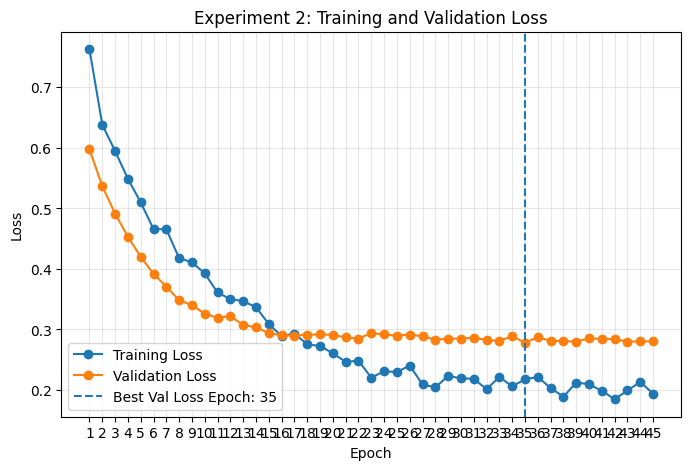

In [ ]:
# ============================================================
# SECTION 12.1: TRAINING AND VALIDATION LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    loss_values,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss_values,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch: {best_val_loss_epoch}"
)

plt.title("Experiment 2: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

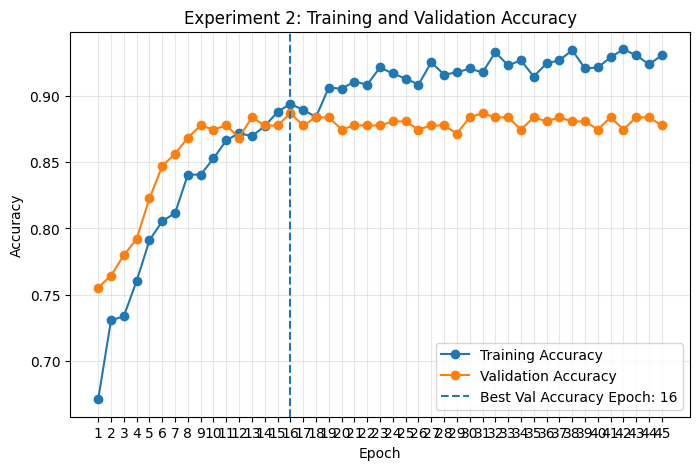

In [ ]:
# ============================================================
# SECTION 12.2: TRAINING AND VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    accuracy_values,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy_values,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_val_accuracy_epoch,
    linestyle="--",
    label=f"Best Val Accuracy Epoch: {best_val_accuracy_epoch}"
)

plt.title("Experiment 2: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Section 13 — Evaluate the Experiment 2 Model

The trained model is evaluated on the unchanged validation set using overall and class-level metrics.

Evaluation includes:

- Accuracy
- Per-class precision
- Per-class recall
- Per-class F1-score
- Macro average
- Micro average
- Weighted average
- Confusion matrix

> **Research note:** Macro F1-score and per-class recall are important because the dataset is imbalanced and the minority classes must be evaluated carefully.

In [ ]:
# ============================================================
# SECTION 13: BASIC VALIDATION EVALUATION
# ============================================================

val_loss, val_accuracy = exp2_model.evaluate(val_ds, verbose=1)

print("Experiment 2 Validation Results")
print("-" * 50)
print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.8838 - loss: 0.2783
Experiment 2 Validation Results
--------------------------------------------------
Validation Loss    : 0.2783
Validation Accuracy: 0.8838


In [ ]:
# ============================================================
# SECTION 13.1: EXTRACT TRUE LABELS AND MODEL PREDICTIONS
# ============================================================

y_true = []
y_pred = []
y_pred_probabilities = []

for images, labels in val_ds:

    predictions = exp2_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
    y_pred_probabilities.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probabilities = np.array(y_pred_probabilities)

print("Number of validation samples :", len(y_true))
print("Number of predictions        :", len(y_pred))
print("Prediction probability shape :", y_pred_probabilities.shape)

Prediction extraction complete.
Number of validation samples : 327
Number of predictions        : 327
Prediction probability shape : (327, 3)


## Section 13.2 — Classification Report

The classification report provides class-level precision, recall, F1-score, and support. This is essential for checking whether partial fine-tuning improves performance across all CDT categories.

In [ ]:
# ============================================================
# SECTION 13.2: CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("Experiment 2 Classification Report")
print("-" * 50)
print(report)

Experiment 2 Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

    Impaired     0.6923    0.5625    0.6207        16
        Mild     0.7800    0.6094    0.6842        64
      Normal     0.9129    0.9757    0.9432       247

    accuracy                         0.8838       327
   macro avg     0.7951    0.7159    0.7494       327
weighted avg     0.8761    0.8838    0.8768       327



In [ ]:
# ============================================================
# SECTION 13.3: MACRO, MICRO, AND WEIGHTED METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Experiment 2 Summary Metrics")
print("-" * 50)
print(f"Accuracy           : {accuracy:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print(f"Micro Precision    : {micro_precision:.4f}")
print(f"Micro Recall       : {micro_recall:.4f}")
print(f"Micro F1-score     : {micro_f1:.4f}")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")

Experiment 2 Summary Metrics
--------------------------------------------------
Accuracy           : 0.8838
Macro Precision    : 0.7951
Macro Recall       : 0.7159
Macro F1-score     : 0.7494
Micro Precision    : 0.8838
Micro Recall       : 0.8838
Micro F1-score     : 0.8838
Weighted Precision : 0.8761
Weighted Recall    : 0.8838
Weighted F1-score  : 0.8768


---
# Section 14 — Confusion Matrix

The confusion matrix shows how predictions are distributed across the actual classes.

For Experiment 2, it is used to examine whether partial fine-tuning reduced majority-class bias and improved recognition of `Impaired` and `Mild` cases.

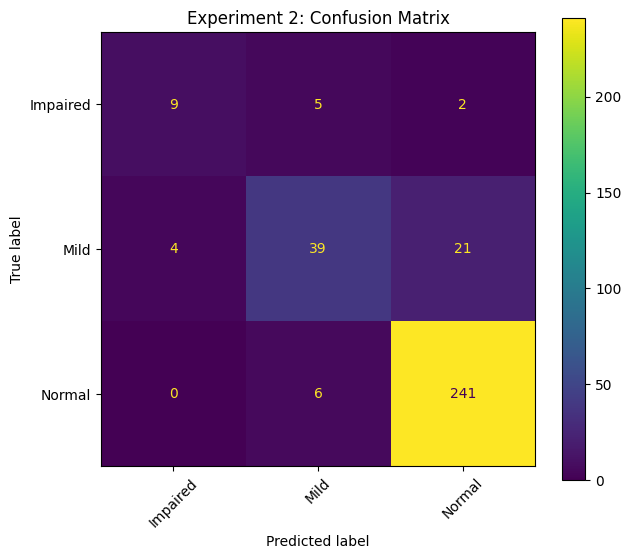

In [ ]:
# ============================================================
# SECTION 14: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

plt.title("Experiment 2: Confusion Matrix")
plt.show()

In [ ]:
# ============================================================
# SECTION 14.1: CONFUSION MATRIX TABLE
# ============================================================

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

confusion_matrix_df

,Predicted Impaired,Predicted Mild,Predicted Normal
Actual Impaired,9,5,2
Actual Mild,4,39,21
Actual Normal,0,6,241


---
# Section 15 — Result Tables

Clean result tables are prepared for documentation and comparison.

The first table presents per-class performance.  
The second table summarizes the overall Experiment 2 results.

In [ ]:
# ============================================================
# SECTION 15: PER-CLASS METRICS TABLE
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    zero_division=0
)

per_class_metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

per_class_metrics_df

,Class,Precision,Recall,F1-score,Support
0,Impaired,0.692308,0.562500,0.620690,16
1,Mild,0.780000,0.609375,0.684211,64
2,Normal,0.912879,0.975709,0.943249,247


In [ ]:
# ============================================================
# SECTION 15.1: EXPERIMENT 2 SUMMARY TABLE
# ============================================================

exp2_summary_df = pd.DataFrame({
    "Experiment": ["Experiment 2 - Partial 30% Fine-Tuning"],
    "Validation Loss": [val_loss],
    "Validation Accuracy": [accuracy],
    "Macro Precision": [macro_precision],
    "Macro Recall": [macro_recall],
    "Macro F1-score": [macro_f1],
    "Micro Precision": [micro_precision],
    "Micro Recall": [micro_recall],
    "Micro F1-score": [micro_f1],
    "Weighted Precision": [weighted_precision],
    "Weighted Recall": [weighted_recall],
    "Weighted F1-score": [weighted_f1],
    "Completed Epochs": [completed_epochs],
    "Best Val Loss": [best_val_loss],
    "Best Val Loss Epoch": [best_val_loss_epoch],
    "Best Val Accuracy": [best_val_accuracy],
    "Best Val Accuracy Epoch": [best_val_accuracy_epoch],
    "Unfreeze Ratio": [unfreeze_ratio],
    "Backbone Layers Unfrozen": [num_layers_to_unfreeze],
    "Backbone Layers Frozen": [total_backbone_layers - num_layers_to_unfreeze]
})

exp2_summary_df

,Experiment,Validation Loss,Validation Accuracy,Macro Precision,Macro Recall,Macro F1-score,Micro Precision,Micro Recall,Micro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Completed Epochs,Best Val Loss,Best Val Loss Epoch,Best Val Accuracy,Best Val Accuracy Epoch,Unfreeze Ratio,Backbone Layers Unfrozen,Backbone Layers Frozen
0,Experiment 2 - Partial 30% Fine-Tuning,0.27834,0.883792,0.795062,0.715861,0.749383,0.883792,0.883792,0.883792,0.876079,0.883792,0.876767,45,0.27834,35,0.88685,16,0.3,21,51


In [ ]:
# ============================================================
# SECTION 15.2: SAVE RESULT TABLES
# ============================================================

per_class_metrics_df.to_csv(PER_CLASS_CSV_PATH, index=False)
exp2_summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

print("Experiment 2 result tables saved successfully.")
print("Per-class metrics saved to:", PER_CLASS_CSV_PATH)
print("Summary metrics saved to  :", SUMMARY_CSV_PATH)

Experiment 2 result tables saved successfully.
Per-class metrics saved to: /content/drive/MyDrive/Colab Notebooks/models/exp2_per_class_metrics.csv
Summary metrics saved to  : /content/drive/MyDrive/Colab Notebooks/models/exp2_summary_metrics.csv


---
# Section 16 — Save the Final Trained Model

The best model is saved automatically through `ModelCheckpoint`. The final in-memory model is also saved after training.

Because early stopping restores the best weights, the saved final model reflects the best validation-loss state reached during training.

In [ ]:
# ============================================================
# SECTION 16: SAVE FINAL MODEL
# ============================================================

exp2_model.save(FINAL_MODEL_PATH)

print("Best checkpoint model:", BEST_MODEL_PATH)
print("Final saved model    :", FINAL_MODEL_PATH)

Final Experiment 2 model saved successfully.
Best checkpoint model: /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_best.keras
Final saved model    : /content/drive/MyDrive/Colab Notebooks/models/exp2_partial30_resnet18_final.keras


## Section 16.1 — Reload Check

It confirms that the saved best model can be loaded again from Google Drive.

In [ ]:
# ============================================================
# SECTION 16.1: SAVED MODEL RELOAD CHECK
# ============================================================

loaded_exp2_model = keras.models.load_model(BEST_MODEL_PATH)

loaded_val_loss, loaded_val_accuracy = loaded_exp2_model.evaluate(val_ds, verbose=0)

print(f"Reloaded model validation loss    : {loaded_val_loss:.4f}")
print(f"Reloaded model validation accuracy: {loaded_val_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 130 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved model reload check complete.
Reloaded model validation loss    : 0.2783
Reloaded model validation accuracy: 0.8838


---
# Section 17 — Experiment 2 Interpretation

The final interpretation summarizes Experiment 2 performance and explains how partial fine-tuning affected CDT classification across the three classes.

## Experiment 2 Result Interpretation

### Overview

Experiment 2 used an ImageNet-pretrained ResNet18 backbone with the **last 30% of backbone layers made trainable**. Earlier layers remained frozen to preserve general pretrained visual features, while the upper layers adapted to Clock Drawing Test images.

This setup tested whether partial fine-tuning could improve performance over the fully frozen baseline.

---

### Overall Performance

| Metric | Experiment 2 Result |
|---|---:|
| Validation Accuracy | **0.8838** |
| Macro Precision | **0.7951** |
| Macro Recall | **0.7159** |
| Macro F1-score | **0.7494** |

Experiment 2 achieved the highest overall accuracy among the three experiments, showing that partial fine-tuning improved general classification performance.

---

### Class-Level Observation

| Class | Recall |
|---|---:|
| Impaired | **0.5625** |
| Mild | **0.6094** |
| Normal | **0.9757** |

The model performed strongest on the `Normal` class and improved `Mild` recall compared with the fully frozen baseline. However, `Impaired` recall remained lower than the full fine-tuning model with imbalance handling.

---

### Comparison with Experiment 1

| Metric | Experiment 1 | Experiment 2 |
|---|---:|---:|
| Validation Accuracy | 0.8226 | **0.8838** |
| Macro Recall | 0.6505 | **0.7159** |
| Macro F1-score | 0.7003 | **0.7494** |

Experiment 2 outperformed the frozen baseline in accuracy, macro recall, and macro F1-score. This suggests that allowing the upper layers of ResNet18 to adapt improved CDT classification performance.

---

### Interpretation

Partial fine-tuning provided a strong balance between preserving pretrained features and adapting to CDT-specific patterns. By unfreezing only the upper 30% of the backbone, the model improved overall performance without fully retraining all ResNet18 layers.

The strong `Normal` recall contributed to the high accuracy, while improvements in macro metrics indicate better class-level performance compared with Experiment 1.

---

### Key Takeaway

Experiment 2 achieved the **highest overall accuracy** among the three experiments. Its results show that partial fine-tuning is effective for improving general CDT classification performance while maintaining stable pretrained feature representations.

---
# Final Note

This notebook completed the partial 30% fine-tuning experiment for Clock Drawing Test image classification.

The results from this experiment are intended for comparison with:

- **Experiment 1:** Fully frozen ResNet18 baseline
- **Experiment 3:** Full fine-tuning with imbalance handling

Final model comparison should consider not only overall accuracy, but also macro F1-score and recall for the `Impaired` and `Mild` classes, since these metrics better reflect screening-sensitive performance.